# 🔐 Real-Time Fraud Detection System with Explainable AI & Live Dashboard
### IEEE-CIS Fraud Detection — Capstone Project
---
**Dataset:** IEEE-CIS Fraud Detection (Kaggle)  
**Models:** LightGBM · XGBoost · Isolation Forest  
**Explainability:** SHAP Values  
**Dashboard:** Streamlit Multi-Page App  

> *This notebook covers all 8 tasks: EDA → Preprocessing → Modelling → SHAP → Risk Segmentation → Dashboard → Visualisations → Business Insights*


## ⚙️ Environment Setup

In [1]:
# Install required libraries (run once)
import subprocess, sys

PACKAGES = [
    "lightgbm", "xgboost", "shap", "imbalanced-learn",
    "optuna", "plotly", "streamlit", "scikit-learn",
    "pandas", "numpy", "matplotlib", "seaborn", "joblib"
]

for pkg in PACKAGES:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ All packages installed successfully.")



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip



✅ All packages installed successfully.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ─── Core Imports ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import joblib
import json
import time

warnings.filterwarnings("ignore")

# ─── ML Libraries ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─── Plotting Defaults ────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})
FRAUD_PALETTE = {"Fraud": "#e74c3c", "Legit": "#2ecc71"}

# ─── Directories ──────────────────────────────────────────────────────────────
os.makedirs("charts", exist_ok=True)
os.makedirs("dashboard", exist_ok=True)
os.makedirs("data", exist_ok=True)

print("✅ Imports complete. Environment ready.")
print(f"   LightGBM  : {lgb.__version__}")
print(f"   XGBoost   : {xgb.__version__}")
print(f"   SHAP      : {shap.__version__}")


✅ Imports complete. Environment ready.
   LightGBM  : 4.6.0
   XGBoost   : 3.2.0
   SHAP      : 0.51.0


---
## TASK 1 — Data Loading, Merging & Exploratory Analysis
> Load both CSVs, merge on `TransactionID`, inspect shape/dtypes, visualise class imbalance, missing values, `TransactionAmt` distributions, and a correlation heatmap.


In [3]:
# ─── 1.1 Load Raw CSVs ────────────────────────────────────────────────────────
t0 = time.time()

print("Loading train_transaction.csv …")
df_trans = pd.read_csv("data/train_transaction.csv")

print("Loading train_identity.csv …")
df_id    = pd.read_csv("data/train_identity.csv")

print(f"\n  Transaction : {df_trans.shape[0]:>7,} rows × {df_trans.shape[1]} cols")
print(f"  Identity    : {df_id.shape[0]:>7,} rows × {df_id.shape[1]} cols")
print(f"  Load time   : {time.time()-t0:.1f}s")


Loading train_transaction.csv …
Loading train_identity.csv …

  Transaction : 590,540 rows × 394 cols
  Identity    : 144,233 rows × 41 cols
  Load time   : 7.4s


In [4]:
# ─── 1.2 Merge on TransactionID (left join keeps all transactions) ────────────
df = pd.merge(df_trans, df_id, on="TransactionID", how="left")

print(f"Merged shape : {df.shape[0]:,} rows × {df.shape[1]} cols")
print("\n--- Data-type summary ---")
print(df.dtypes.value_counts().to_string())
print("\n--- First 10 rows (selected columns) ---")
df[["TransactionID","isFraud","TransactionAmt","ProductCD","card4","card6"]].head(10)


Merged shape : 590,540 rows × 434 cols

--- Data-type summary ---
float64    399
str         31
int64        4

--- First 10 rows (selected columns) ---


,TransactionID,isFraud,TransactionAmt,ProductCD,card4,card6
0,2987000,0,68.5,W,discover,credit
1,2987001,0,29.0,W,mastercard,credit
2,2987002,0,59.0,W,visa,debit
3,2987003,0,50.0,W,mastercard,debit
4,2987004,0,50.0,H,mastercard,credit
5,2987005,0,49.0,W,visa,debit
6,2987006,0,159.0,W,visa,debit
7,2987007,0,422.5,W,visa,debit
8,2987008,0,15.0,H,visa,debit
9,2987009,0,117.0,W,mastercard,debit


Total transactions : 590,540
Fraud (1)          : 20,663  (3.50%)
Legit (0)          : 569,877  (96.50%)


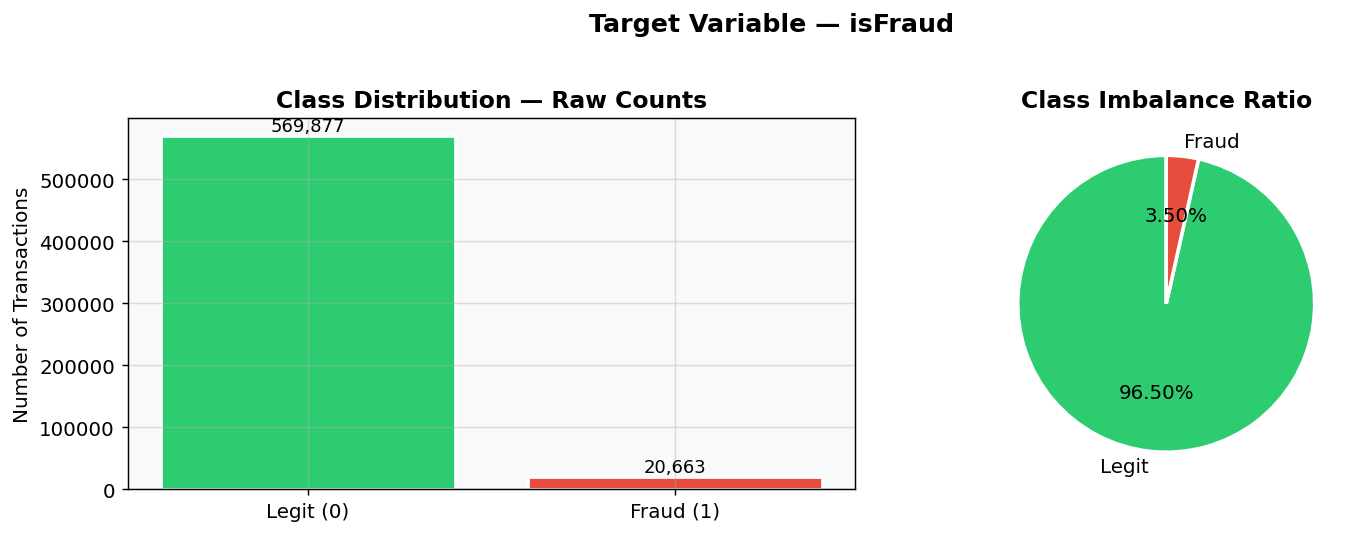


⚠️  Severe class imbalance detected — standard accuracy is misleading.
    PR-AUC and F1-Score will be the primary evaluation metrics.


In [5]:
# ─── 1.3 Target Distribution ──────────────────────────────────────────────────
fraud_counts = df["isFraud"].value_counts()
fraud_rate   = df["isFraud"].mean() * 100

print(f"Total transactions : {len(df):,}")
print(f"Fraud (1)          : {fraud_counts[1]:,}  ({fraud_rate:.2f}%)")
print(f"Legit (0)          : {fraud_counts[0]:,}  ({100-fraud_rate:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count bar
axes[0].bar(["Legit (0)", "Fraud (1)"],
            [fraud_counts[0], fraud_counts[1]],
            color=["#2ecc71", "#e74c3c"], edgecolor="white", linewidth=1.5)
axes[0].set_title("Class Distribution — Raw Counts")
axes[0].set_ylabel("Number of Transactions")
for bar, val in zip(axes[0].patches, [fraud_counts[0], fraud_counts[1]]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                 f"{val:,}", ha="center", va="bottom", fontsize=10)

# Pie
axes[1].pie([fraud_counts[0], fraud_counts[1]],
            labels=["Legit", "Fraud"],
            colors=["#2ecc71", "#e74c3c"],
            autopct="%1.2f%%", startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("Class Imbalance Ratio")

plt.suptitle("Target Variable — isFraud", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("charts/class_imbalance.png", bbox_inches="tight")
plt.show()
print("\n⚠️  Severe class imbalance detected — standard accuracy is misleading.")
print("    PR-AUC and F1-Score will be the primary evaluation metrics.")


Columns with missing values : 414
Columns with >50% missing   : 214


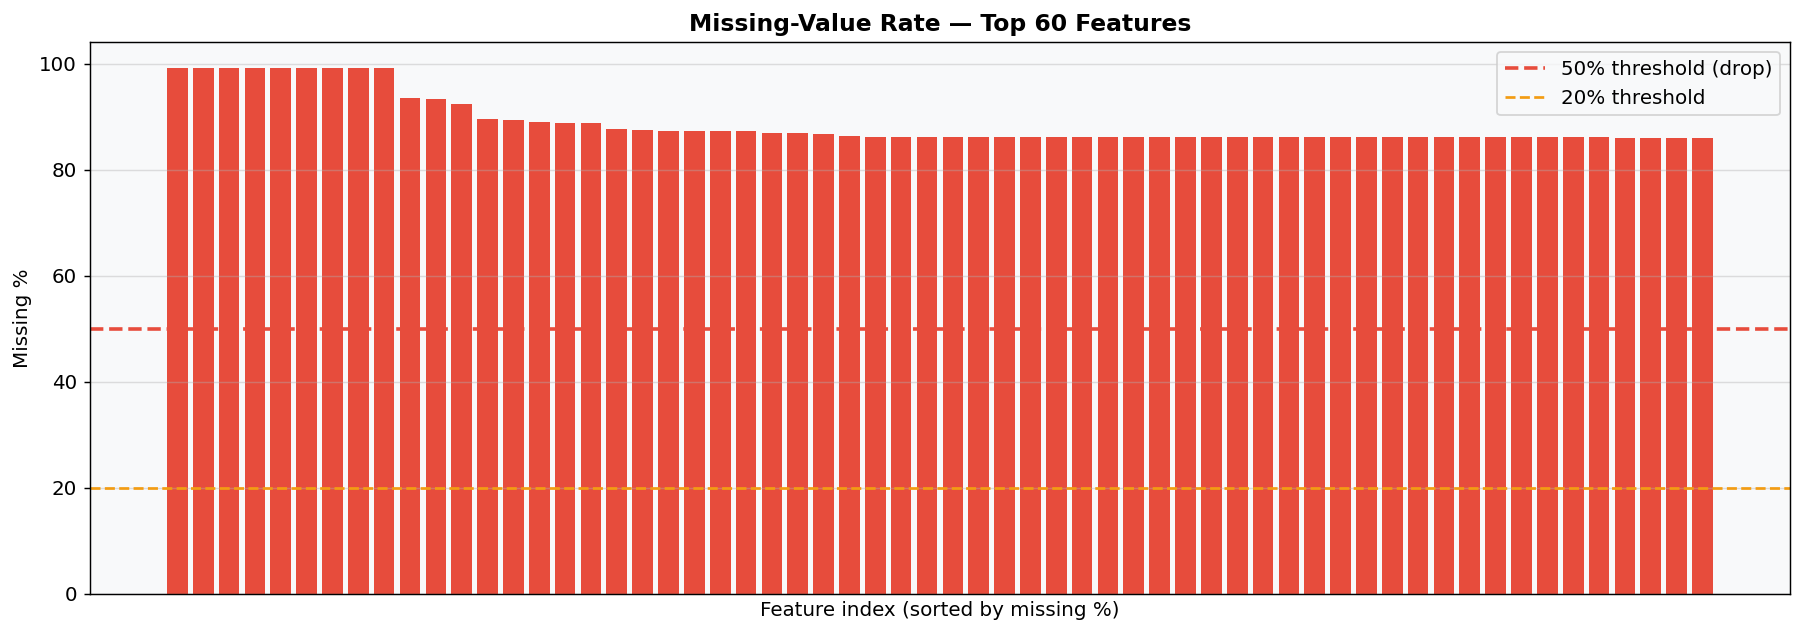

In [6]:
# ─── 1.4 Missing-Value Analysis ───────────────────────────────────────────────
miss = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
miss = miss[miss > 0]

print(f"Columns with missing values : {len(miss)}")
print(f"Columns with >50% missing   : {(miss>50).sum()}")

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#e74c3c" if v > 50 else "#f39c12" if v > 20 else "#3498db"
          for v in miss.head(60).values]
ax.bar(range(len(miss.head(60))), miss.head(60).values, color=colors)
ax.axhline(50, color="#e74c3c", linestyle="--", linewidth=2, label="50% threshold (drop)")
ax.axhline(20, color="#f39c12", linestyle="--", linewidth=1.5, label="20% threshold")
ax.set_xticks([])
ax.set_xlabel("Feature index (sorted by missing %)")
ax.set_ylabel("Missing %")
ax.set_title("Missing-Value Rate — Top 60 Features")
ax.legend()
plt.tight_layout()
plt.savefig("charts/missing_values.png", bbox_inches="tight")
plt.show()


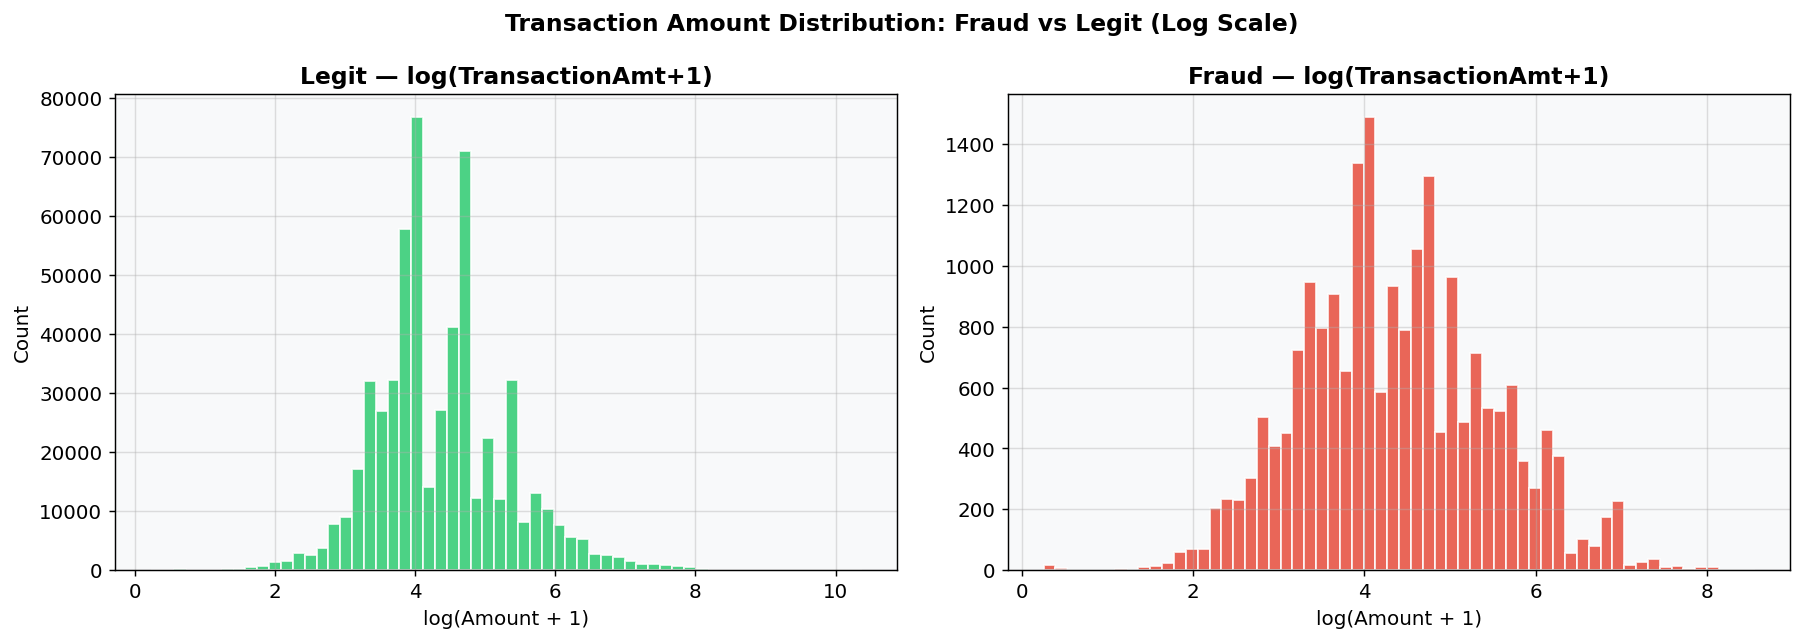

Legit   median : $68.50   mean: $134.51
Fraud   median : $75.00  mean: $149.24


In [7]:
# ─── 1.5 TransactionAmt Distribution (log scale) ──────────────────────────────
fraud_amt = df.loc[df["isFraud"]==1, "TransactionAmt"]
legit_amt = df.loc[df["isFraud"]==0, "TransactionAmt"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — log-x
for ax_i, (data, label, color) in zip(
        axes,
        [(legit_amt,"Legit","#2ecc71"),(fraud_amt,"Fraud","#e74c3c")]):
    ax_i.hist(np.log1p(data), bins=60, color=color, alpha=0.85, edgecolor="white")
    ax_i.set_title(f"{label} — log(TransactionAmt+1)")
    ax_i.set_xlabel("log(Amount + 1)")
    ax_i.set_ylabel("Count")

plt.suptitle("Transaction Amount Distribution: Fraud vs Legit (Log Scale)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/transaction_amt_dist.png", bbox_inches="tight")
plt.show()

print(f"Legit   median : ${legit_amt.median():.2f}   mean: ${legit_amt.mean():.2f}")
print(f"Fraud   median : ${fraud_amt.median():.2f}  mean: ${fraud_amt.mean():.2f}")


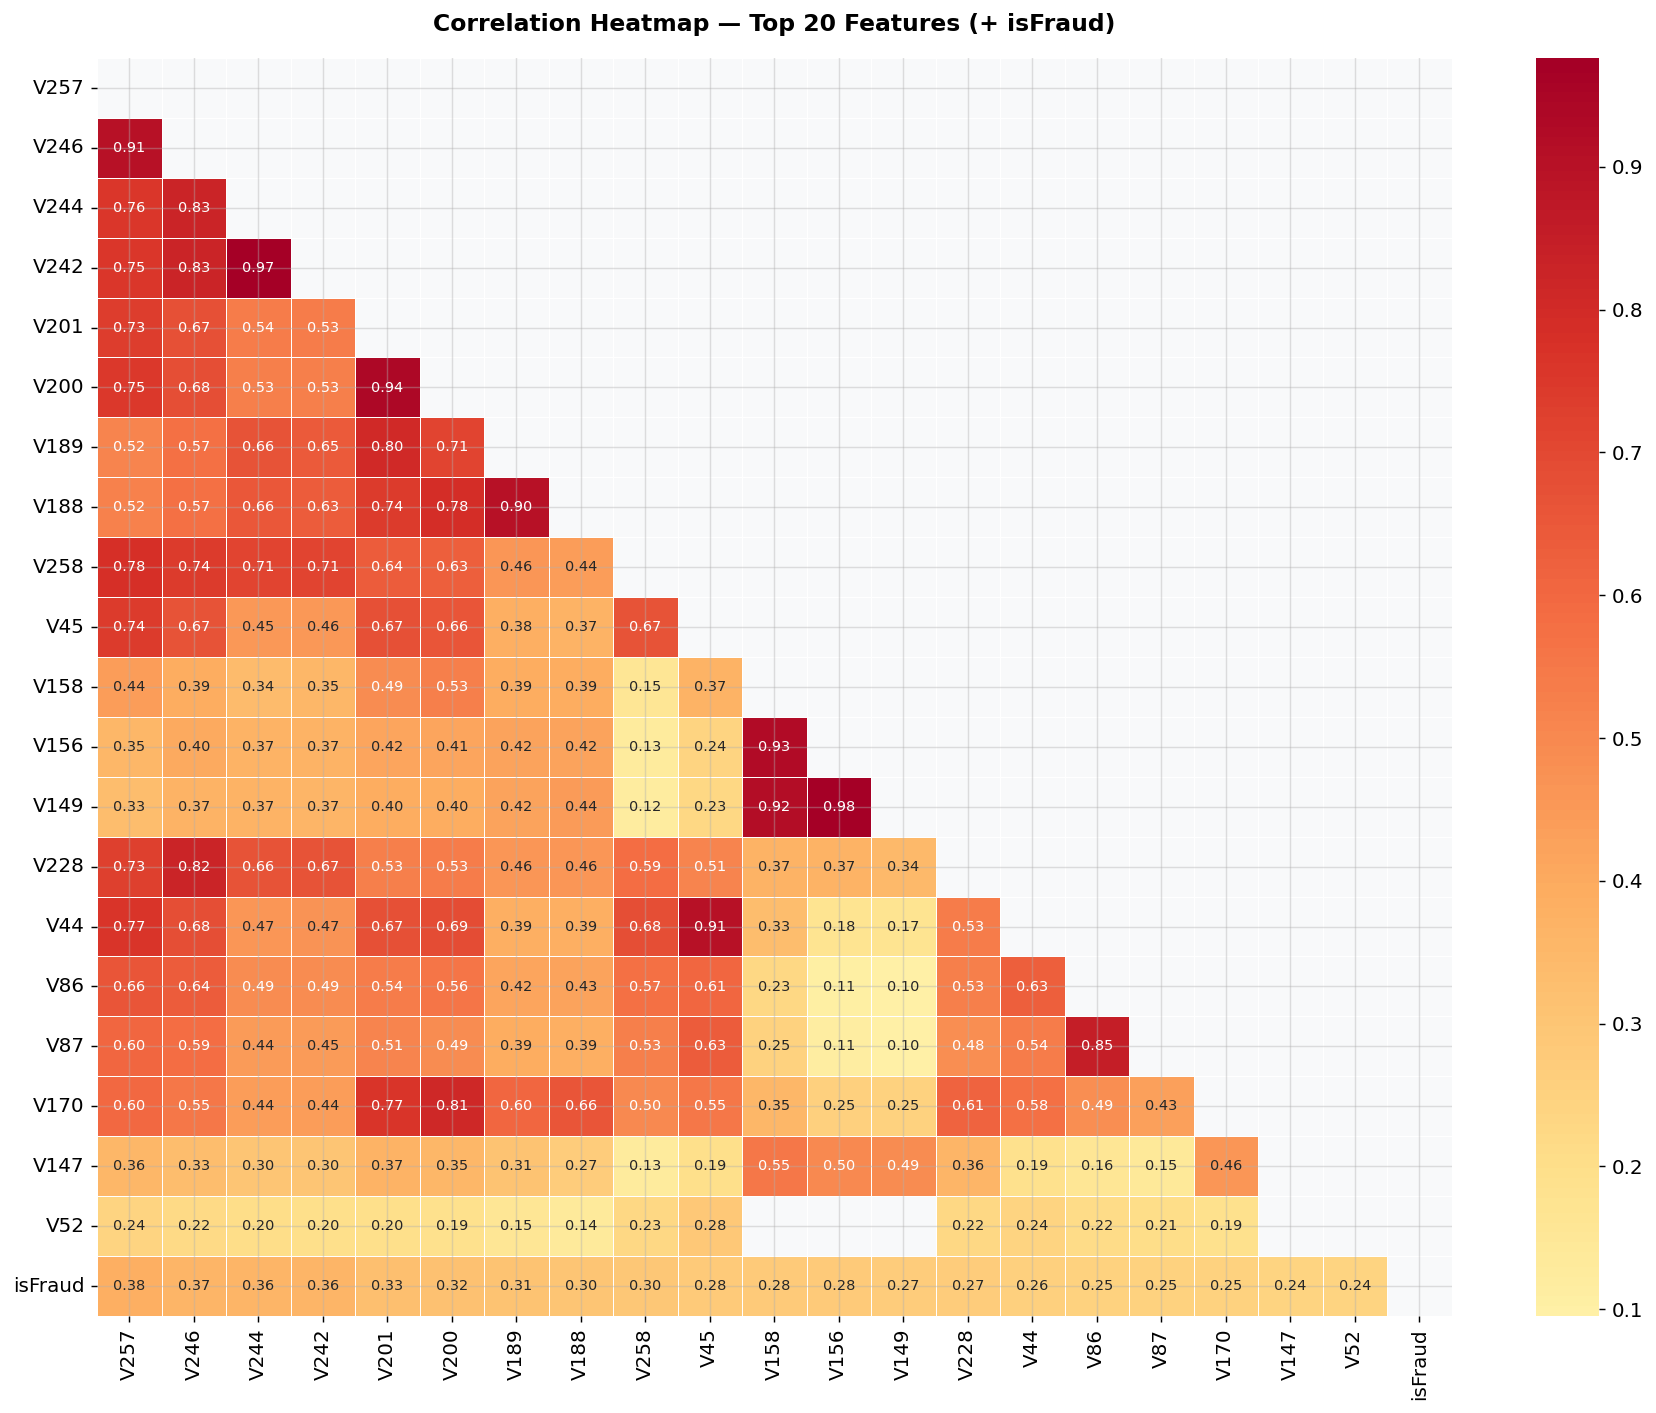

In [8]:
# ─── 1.6 Correlation Heatmap — Top 20 Numerical Features ─────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["TransactionID","isFraud"]]

# Select top 20 by absolute correlation with isFraud
top20 = (df[num_cols].corrwith(df["isFraud"])
           .abs().nlargest(20).index.tolist())
top20.append("isFraud")

corr = df[top20].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn_r", center=0, linewidths=0.5,
            annot_kws={"size":8}, ax=ax)
ax.set_title("Correlation Heatmap — Top 20 Features (+ isFraud)", pad=15)
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", bbox_inches="tight")
plt.show()


---
## TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

### Strategy
| Issue | Decision |
|---|---|
| Columns >50% missing | **Drop** — insufficient signal, imputing would inject noise |
| Numeric columns ≤50% missing | **Median imputation** — robust to outliers |
| Categorical columns ≤50% missing | **Mode imputation** — preserves dominant category |
| High-cardinality categoricals | **Label Encoding** — tree models handle ordinal encodings natively |
| Class imbalance | **SMOTE on training set only** — prevents data leakage |
| Feature scaling | **RobustScaler** — median/IQR based, handles extreme fraud amounts |


In [9]:
# ─── 2.1 Drop High-Missing Columns (>50%) ────────────────────────────────────
miss_pct   = df.isnull().mean()
drop_cols  = miss_pct[miss_pct > 0.50].index.tolist()

# Never drop the target
drop_cols  = [c for c in drop_cols if c != "isFraud"]

print(f"Dropping {len(drop_cols)} columns with >50% missing values.")
df.drop(columns=drop_cols, inplace=True)
print(f"Remaining shape: {df.shape}")


Dropping 214 columns with >50% missing values.
Remaining shape: (590540, 220)


In [10]:
# ─── 2.2 Feature Engineering (3 custom features) ─────────────────────────────

# Feature 1 — Amount-to-Mean Ratio
#   Measures how unusual this transaction is relative to the global mean.
#   High values (very large amounts) are classic fraud signals.
mean_amt = df["TransactionAmt"].mean()
df["AmtToMeanRatio"] = df["TransactionAmt"] / mean_amt

# Feature 2 — Hour of Day
#   TransactionDT is seconds since a reference point.
#   Fraudsters often operate at unusual hours (late night / early morning).
df["HourOfDay"] = (df["TransactionDT"] / 3600 % 24).astype(int)

# Feature 3 — Device Risk Flag
#   Transactions without device info are riskier (no fingerprint available).
has_device_col = "DeviceType" if "DeviceType" in df.columns else None
if has_device_col:
    df["DeviceRisk"] = df["DeviceType"].isnull().astype(int)
else:
    df["DeviceRisk"] = 0

print("✅ Engineered features added:")
print("   AmtToMeanRatio — Amount / Global Mean")
print("   HourOfDay      — Hour extracted from TransactionDT")
print("   DeviceRisk     — 1 if DeviceType is missing, else 0")


✅ Engineered features added:
   AmtToMeanRatio — Amount / Global Mean
   HourOfDay      — Hour extracted from TransactionDT
   DeviceRisk     — 1 if DeviceType is missing, else 0


In [11]:
# ─── 2.3 Imputation ───────────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Numeric — median
for col in num_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# Categorical — mode
for col in cat_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f"Remaining nulls after imputation: {df.isnull().sum().sum()}")


Remaining nulls after imputation: 14036680


In [12]:
# ─── 2.4 Label Encoding for Categorical Columns ───────────────────────────────
le = LabelEncoder()
label_encoders = {}

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print(f"Label-encoded {len(cat_cols)} categorical columns: {cat_cols[:10]} ...")


Label-encoded 9 categorical columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M6'] ...


In [13]:
# ─── 2.5 Train-Test Split (Stratified 80/20) ─────────────────────────────────
FEATURE_COLS = [c for c in df.columns
                if c not in ["TransactionID", "isFraud"]]

X = df[FEATURE_COLS]
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"\nPre-SMOTE class ratio (train):")
print(f"  Legit  : {(y_train==0).sum():,}  ({(y_train==0).mean()*100:.2f}%)")
print(f"  Fraud  : {(y_train==1).sum():,}  ({(y_train==1).mean()*100:.2f}%)")


Training set   : 472,432 rows
Test set       : 118,108 rows

Pre-SMOTE class ratio (train):
  Legit  : 455,902  (96.50%)
  Fraud  : 16,530  (3.50%)


In [14]:
# ─── 2.6 SMOTE (applied only to training set — no data leakage) ──────────────
print("Applying SMOTE to training data …")

# ── Force-fill any remaining NaNs before SMOTE ──────────────────────────────
# Numeric columns → fill with median
X_train = X_train.fillna(X_train.median(numeric_only=True))
# Any columns still NaN (all-NaN columns, categoricals) → fill with 0
X_train = X_train.fillna(0)

# Confirm zero NaNs remain
remaining_nans = X_train.isnull().sum().sum()
print(f"NaNs remaining in X_train before SMOTE: {remaining_nans}")

smote = SMOTE(sampling_strategy=0.3, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nPost-SMOTE class ratio (train):")
print(f"  Legit  : {(y_train_sm==0).sum():,}  ({(y_train_sm==0).mean()*100:.2f}%)")
print(f"  Fraud  : {(y_train_sm==1).sum():,}  ({(y_train_sm==1).mean()*100:.2f}%)")
print(f"  Total  : {len(X_train_sm):,} synthetic + real samples")

print(f"\nPost-SMOTE class ratio (train):")
print(f"  Legit  : {(y_train_sm==0).sum():,}  ({(y_train_sm==0).mean()*100:.2f}%)")
print(f"  Fraud  : {(y_train_sm==1).sum():,}  ({(y_train_sm==1).mean()*100:.2f}%)")
print(f"  Total  : {len(X_train_sm):,} synthetic + real samples")


Applying SMOTE to training data …
NaNs remaining in X_train before SMOTE: 0

Post-SMOTE class ratio (train):
  Legit  : 455,902  (76.92%)
  Fraud  : 136,770  (23.08%)
  Total  : 592,672 synthetic + real samples

Post-SMOTE class ratio (train):
  Legit  : 455,902  (76.92%)
  Fraud  : 136,770  (23.08%)
  Total  : 592,672 synthetic + real samples


In [15]:
# ─── 2.7 RobustScaler ─────────────────────────────────────────────────────────
#   Uses median and IQR — immune to extreme transaction-amount outliers.
scaler = RobustScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train_sm),
    columns=FEATURE_COLS
)
X_test_sc  = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURE_COLS
)

# Save scaler for dashboard
joblib.dump(scaler, "dashboard/scaler.pkl")
print("✅ RobustScaler fitted and saved to dashboard/scaler.pkl")


✅ RobustScaler fitted and saved to dashboard/scaler.pkl


---
## TASK 3 — Model Training, Comparison & Threshold Optimisation
Training three classifiers on SMOTE-balanced data and evaluating with six metrics.


In [16]:
# ─── 3.1 Shared Evaluation Helper ────────────────────────────────────────────
def evaluate_model(name, y_true, y_prob, threshold=0.5):
    """Return a metrics dict for a binary classifier."""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "Model"     : name,
        "Threshold" : threshold,
        "Accuracy"  : accuracy_score(y_true, y_pred),
        "Precision" : precision_score(y_true, y_pred, zero_division=0),
        "Recall"    : recall_score(y_true, y_pred, zero_division=0),
        "F1"        : f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC"   : roc_auc_score(y_true, y_prob),
        "PR-AUC"    : average_precision_score(y_true, y_prob),
    }

results = []   # will collect metrics for all models


In [17]:
# ─── 3.2 Model 1 — LightGBM ──────────────────────────────────────────────────
print("Training LightGBM …")

lgb_params = {
    "objective"       : "binary",
    "metric"          : "average_precision",
    "n_estimators"    : 1000,
    "learning_rate"   : 0.05,
    "num_leaves"      : 63,
    "max_depth"       : -1,
    "min_child_samples": 20,
    "subsample"       : 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha"       : 0.1,
    "reg_lambda"      : 0.1,
    "scale_pos_weight": 1,
    "random_state"    : 42,
    "n_jobs"          : -1,
    "verbose"         : -1,
}

lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(
    X_train_sc, y_train_sm,
    eval_set=[(X_test_sc, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)]
)

lgb_prob  = lgb_model.predict_proba(X_test_sc)[:, 1]
lgb_metrics = evaluate_model("LightGBM", y_test, lgb_prob)
results.append(lgb_metrics)

print(f"  ROC-AUC : {lgb_metrics['ROC-AUC']:.4f}")
print(f"  PR-AUC  : {lgb_metrics['PR-AUC']:.4f}")
print(f"  F1      : {lgb_metrics['F1']:.4f}")

joblib.dump(lgb_model, "dashboard/model.pkl")
print("\n✅ LightGBM saved to dashboard/model.pkl (primary production model)")


Training LightGBM …
  ROC-AUC : 0.9630
  PR-AUC  : 0.8031
  F1      : 0.7071

✅ LightGBM saved to dashboard/model.pkl (primary production model)


In [18]:
# ─── 3.3 Model 2 — XGBoost ───────────────────────────────────────────────────
print("Training XGBoost …")

xgb_params = {
    "objective"          : "binary:logistic",
    "eval_metric"        : "aucpr",
    "n_estimators"       : 500,
    "learning_rate"      : 0.05,
    "max_depth"          : 6,
    "min_child_weight"   : 10,
    "subsample"          : 0.8,
    "colsample_bytree"   : 0.8,
    "gamma"              : 0.1,
    "reg_alpha"          : 0.1,
    "reg_lambda"         : 1.0,
    "early_stopping_rounds": 50,   # ← moved here into constructor
    "random_state"       : 42,
    "n_jobs"             : -1,
    "verbosity"          : 0,
}

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train_sc, y_train_sm,
    eval_set=[(X_test_sc, y_test)],
    verbose=False                  # ← only verbose stays in .fit()
)

xgb_prob    = xgb_model.predict_proba(X_test_sc)[:, 1]
xgb_metrics = evaluate_model("XGBoost", y_test, xgb_prob)
results.append(xgb_metrics)

print(f"  ROC-AUC : {xgb_metrics['ROC-AUC']:.4f}")
print(f"  PR-AUC  : {xgb_metrics['PR-AUC']:.4f}")
print(f"  F1      : {xgb_metrics['F1']:.4f}")

Training XGBoost …
  ROC-AUC : 0.9125
  PR-AUC  : 0.6033
  F1      : 0.4864


In [19]:
# ─── 3.4 Model 3 — Isolation Forest (Unsupervised Anomaly Detector) ───────────
print("Training Isolation Forest …")

#   Isolation Forest is unsupervised — does not use SMOTE-augmented labels.
#   It assigns anomaly scores; we invert and normalise to [0,1] as pseudo-probabilities.
iso_model = IsolationForest(
    n_estimators  = 300,
    contamination = df["isFraud"].mean(),
    max_samples   = "auto",
    random_state  = 42,
    n_jobs        = -1
)
iso_model.fit(X_train_sc)

# score_samples returns negative — lower = more anomalous
iso_scores = -iso_model.score_samples(X_test_sc)
iso_prob   = (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())

iso_metrics = evaluate_model("Isolation Forest", y_test, iso_prob)
results.append(iso_metrics)

print(f"  ROC-AUC : {iso_metrics['ROC-AUC']:.4f}")
print(f"  PR-AUC  : {iso_metrics['PR-AUC']:.4f}")
print(f"  F1      : {iso_metrics['F1']:.4f}")


Training Isolation Forest …
  ROC-AUC : 0.6958
  PR-AUC  : 0.0969
  F1      : 0.0877


In [20]:
# ─── 3.5 Model Comparison Table ───────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df[["Accuracy","Precision","Recall","F1","ROC-AUC","PR-AUC","Threshold"]]

styled = results_df.style \
    .format("{:.4f}") \
    .background_gradient(cmap="YlOrRd", axis=0,
                         subset=["Accuracy","Precision","Recall","F1","ROC-AUC","PR-AUC"]) \
    .set_caption("Model Performance Comparison (default threshold = 0.50)")

print("\n=== MODEL COMPARISON ===")
print(results_df.to_string())

# Save comparison PNG
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")
tbl = ax.table(
    cellText=results_df.round(4).values,
    rowLabels=results_df.index,
    colLabels=results_df.columns,
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
plt.title("Model Performance Comparison", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight")
plt.close()
print("\n✅ Saved model_comparison.png")



=== MODEL COMPARISON ===
                  Accuracy  Precision    Recall        F1   ROC-AUC    PR-AUC  Threshold
Model                                                                                   
LightGBM          0.983481   0.931566  0.569804  0.707101  0.962961  0.803138        0.5
XGBoost           0.975091   0.873354  0.337043  0.486383  0.912514  0.603319        0.5
Isolation Forest  0.958428   0.188951  0.057101  0.087700  0.695820  0.096859        0.5

✅ Saved model_comparison.png


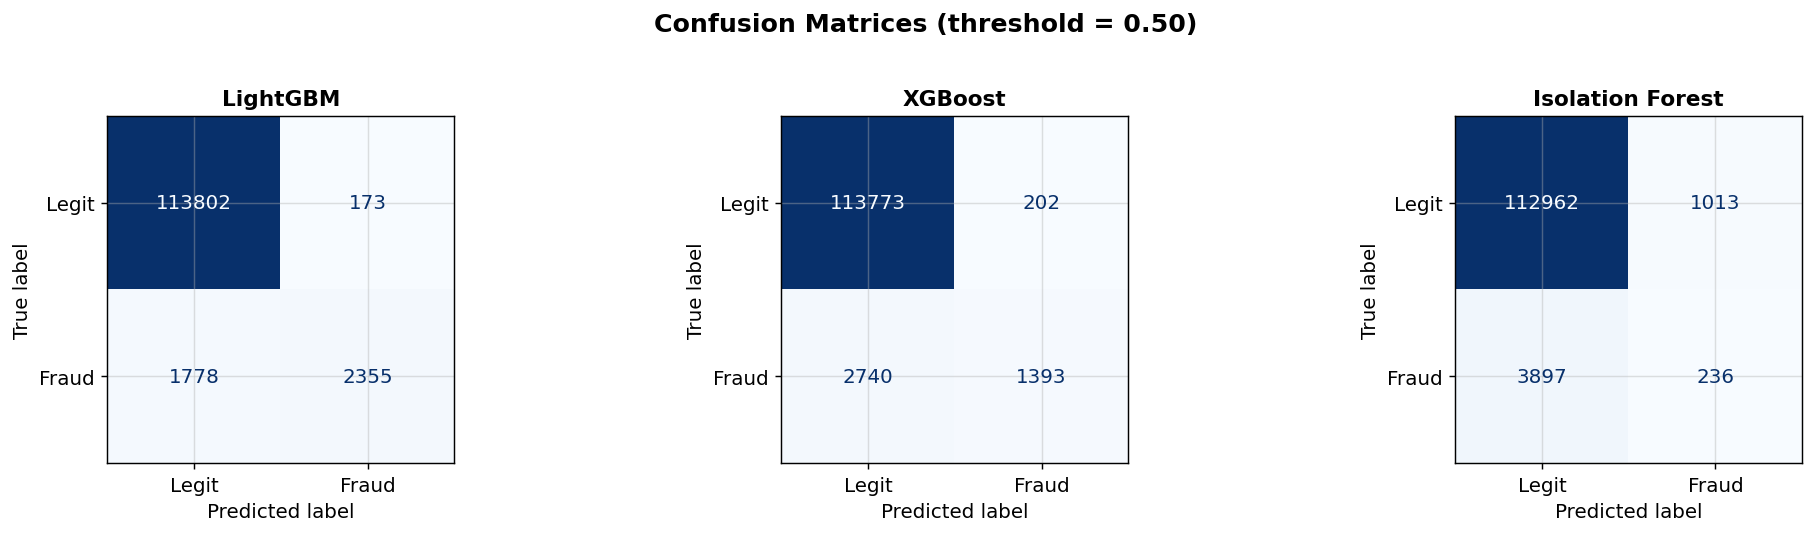

In [21]:
# ─── 3.6 Confusion Matrices ───────────────────────────────────────────────────
model_probs = [
    ("LightGBM",       lgb_prob),
    ("XGBoost",        xgb_prob),
    ("Isolation Forest", iso_prob),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, prob) in zip(axes, model_probs):
    pred = (prob >= 0.5).astype(int)
    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legit","Fraud"])
    disp.plot(ax=ax, colorbar=False,
              cmap="Blues", values_format="d")
    ax.set_title(f"{name}", fontsize=12)

plt.suptitle("Confusion Matrices (threshold = 0.50)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("charts/confusion_matrices.png", bbox_inches="tight")
plt.show()


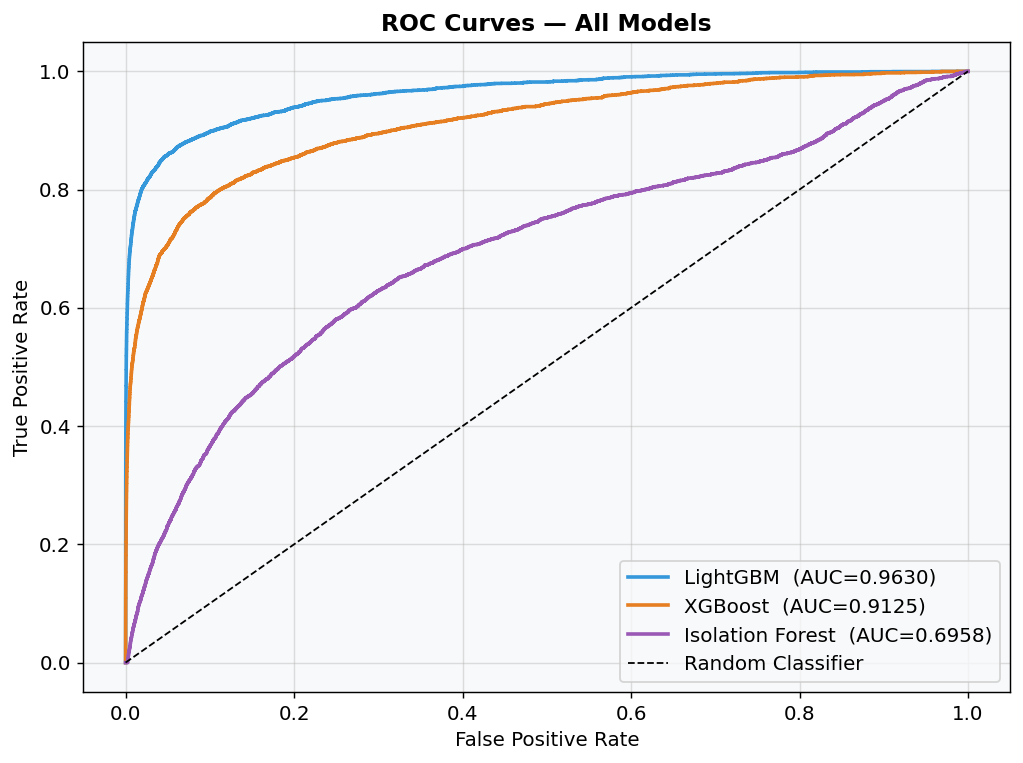

In [22]:
# ─── 3.7 ROC Curves ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

colors_roc = ["#3498db", "#e67e22", "#9b59b6"]
for (name, prob), color in zip(model_probs, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f"{name}  (AUC={auc:.4f})", color=color, lw=2)

ax.plot([0,1],[0,1],"k--", lw=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("charts/roc_curves.png", bbox_inches="tight")
plt.show()


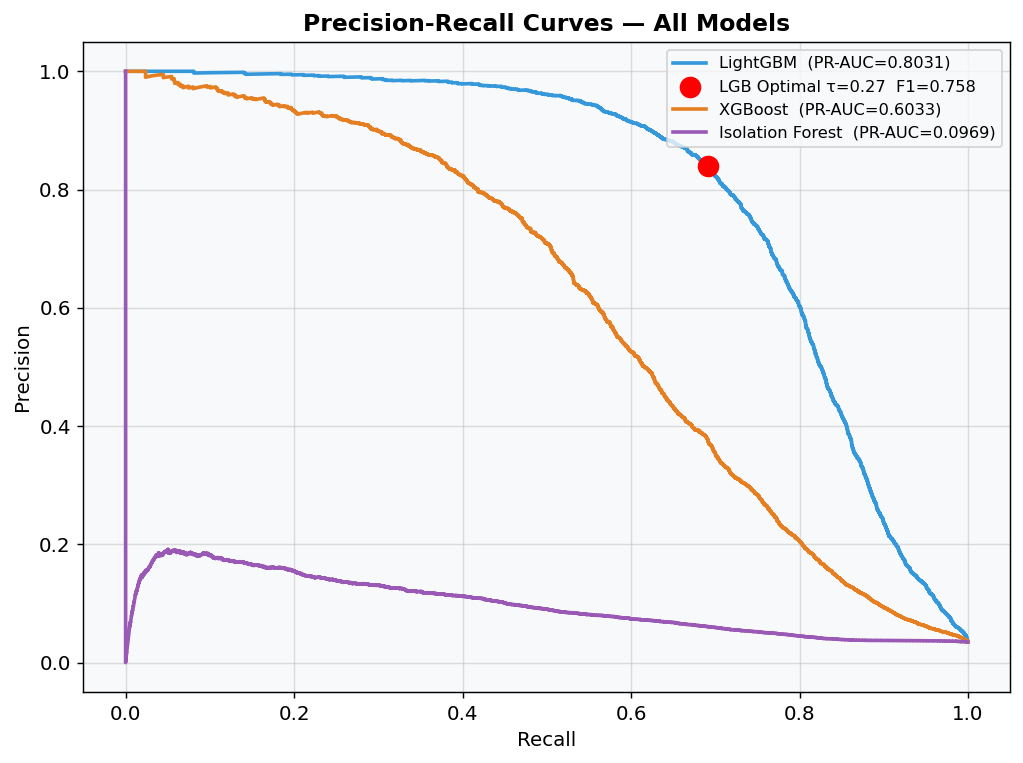


LightGBM optimal threshold : 0.2658
LightGBM @ optimal threshold:
{'Model': 'LightGBM (optimal τ)', 'Threshold': np.float64(0.2657762624375849), 'Accuracy': 0.9845988417380702, 'Precision': 0.8404944084755739, 'Recall': 0.691023469634648, 'F1': 0.7584650112866818, 'ROC-AUC': 0.9629611544676467, 'PR-AUC': 0.8031381618837843}


In [23]:
# ─── 3.8 Precision-Recall Curves ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for (name, prob), color in zip(model_probs, colors_roc):
    prec, rec, thresholds = precision_recall_curve(y_test, prob)
    prauc = average_precision_score(y_test, prob)

    # Find optimal threshold by F1
    f1_scores   = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
    best_idx    = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1     = f1_scores[best_idx]

    ax.plot(rec, prec, label=f"{name}  (PR-AUC={prauc:.4f})", color=color, lw=2)
    if name == "LightGBM":
        ax.scatter(rec[best_idx], prec[best_idx],
                   color="red", zorder=5, s=120,
                   label=f"LGB Optimal τ={best_thresh:.2f}  F1={best_f1:.3f}")
        OPTIMAL_THRESHOLD = best_thresh

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All Models")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("charts/pr_curves.png", bbox_inches="tight")
plt.show()

print(f"\nLightGBM optimal threshold : {OPTIMAL_THRESHOLD:.4f}")
print(f"LightGBM @ optimal threshold:")
print(evaluate_model("LightGBM (optimal τ)", y_test, lgb_prob, OPTIMAL_THRESHOLD))


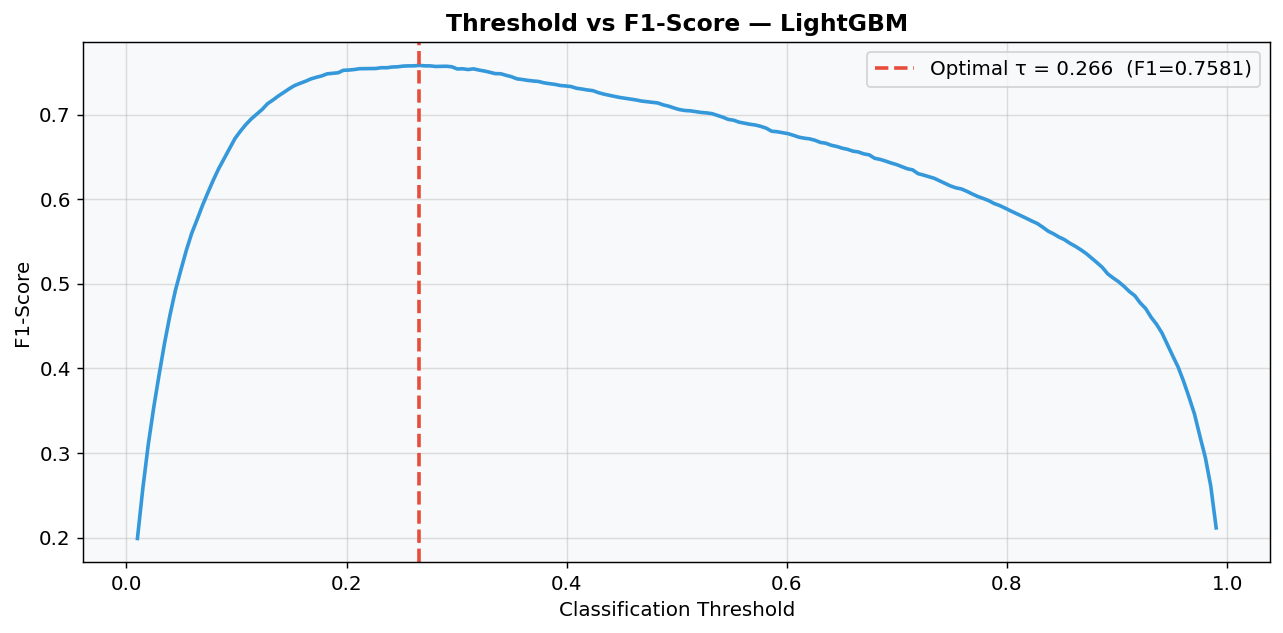

In [24]:
# ─── 3.9 Threshold vs F1-Score Plot (LightGBM) ───────────────────────────────
thresholds_range = np.linspace(0.01, 0.99, 200)
f1_list = [
    f1_score(y_test, (lgb_prob >= t).astype(int), zero_division=0)
    for t in thresholds_range
]
best_t = thresholds_range[np.argmax(f1_list)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_range, f1_list, color="#3498db", lw=2)
ax.axvline(best_t, color="#e74c3c", linestyle="--", lw=2,
           label=f"Optimal τ = {best_t:.3f}  (F1={max(f1_list):.4f})")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("F1-Score")
ax.set_title("Threshold vs F1-Score — LightGBM")
ax.legend()
plt.tight_layout()
plt.savefig("charts/threshold_f1.png", bbox_inches="tight")
plt.show()


In [25]:
# ─── 3.10 Hyperparameter Tuning with Optuna (LightGBM) ───────────────────────
print("Running Optuna hyperparameter search (50 trials) …")

def lgb_objective(trial):
    params = {
        "objective"        : "binary",
        "metric"           : "average_precision",
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 20, 150),
        "max_depth"        : trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "verbose"          : -1,
        "random_state"     : 42,
        "n_jobs"           : -1,
    }
    m = lgb.LGBMClassifier(**params)
    m.fit(X_train_sc, y_train_sm,
          eval_set=[(X_test_sc, y_test)],
          callbacks=[lgb.early_stopping(30, verbose=False),
                     lgb.log_evaluation(period=-1)])
    prob = m.predict_proba(X_test_sc)[:, 1]
    return average_precision_score(y_test, prob)

study = optuna.create_study(direction="maximize")
study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ Best PR-AUC : {study.best_value:.4f}")
print(f"   Best params : {study.best_params}")

# Retrain with best params
best_lgb = lgb.LGBMClassifier(
    **study.best_params, objective="binary", metric="average_precision",
    verbose=-1, random_state=42, n_jobs=-1
)
best_lgb.fit(X_train_sc, y_train_sm,
             eval_set=[(X_test_sc, y_test)],
             callbacks=[lgb.early_stopping(50, verbose=False),
                        lgb.log_evaluation(period=-1)])

tuned_prob    = best_lgb.predict_proba(X_test_sc)[:, 1]
tuned_metrics = evaluate_model("LightGBM (Tuned)", y_test, tuned_prob)
print("\nTuned model metrics:")
for k, v in tuned_metrics.items():
    print(f"  {k:12s}: {v}")

joblib.dump(best_lgb, "dashboard/model.pkl")
lgb_model = best_lgb
lgb_prob  = tuned_prob
print("\n✅ Tuned model saved to dashboard/model.pkl")


Running Optuna hyperparameter search (50 trials) …


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best PR-AUC : 0.8525
   Best params : {'n_estimators': 1397, 'learning_rate': 0.1273042830207902, 'num_leaves': 97, 'max_depth': 9, 'min_child_samples': 27, 'subsample': 0.7588252567639134, 'colsample_bytree': 0.6826035163956514, 'reg_alpha': 0.8444161930542209, 'reg_lambda': 0.011750731521626505}

Tuned model metrics:
  Model       : LightGBM (Tuned)
  Threshold   : 0.5
  Accuracy    : 0.986961086463237
  Precision   : 0.9478411053540587
  Recall      : 0.6639245100411324
  F1          : 0.7808764940239044
  ROC-AUC     : 0.9705359125378596
  PR-AUC      : 0.852476342395896

✅ Tuned model saved to dashboard/model.pkl


---
## TASK 4 — Explainable AI with SHAP Values
Using SHAP TreeExplainer for model-agnostic feature attribution.


In [26]:
# ─── 4.1 SHAP Explainer (TreeExplainer is fastest for tree models) ────────────
print("Computing SHAP values (this may take 2-5 minutes) …")

# Use a representative sample for global plots (speeds up computation)
SHAP_SAMPLE = min(3000, len(X_test_sc))
X_shap = X_test_sc.sample(n=SHAP_SAMPLE, random_state=42)

explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer(X_shap)

print(f"✅ SHAP values computed for {SHAP_SAMPLE} test samples.")
print(f"   shap_values shape : {shap_values.values.shape}")


Computing SHAP values (this may take 2-5 minutes) …
✅ SHAP values computed for 3000 test samples.
   shap_values shape : (3000, 221)


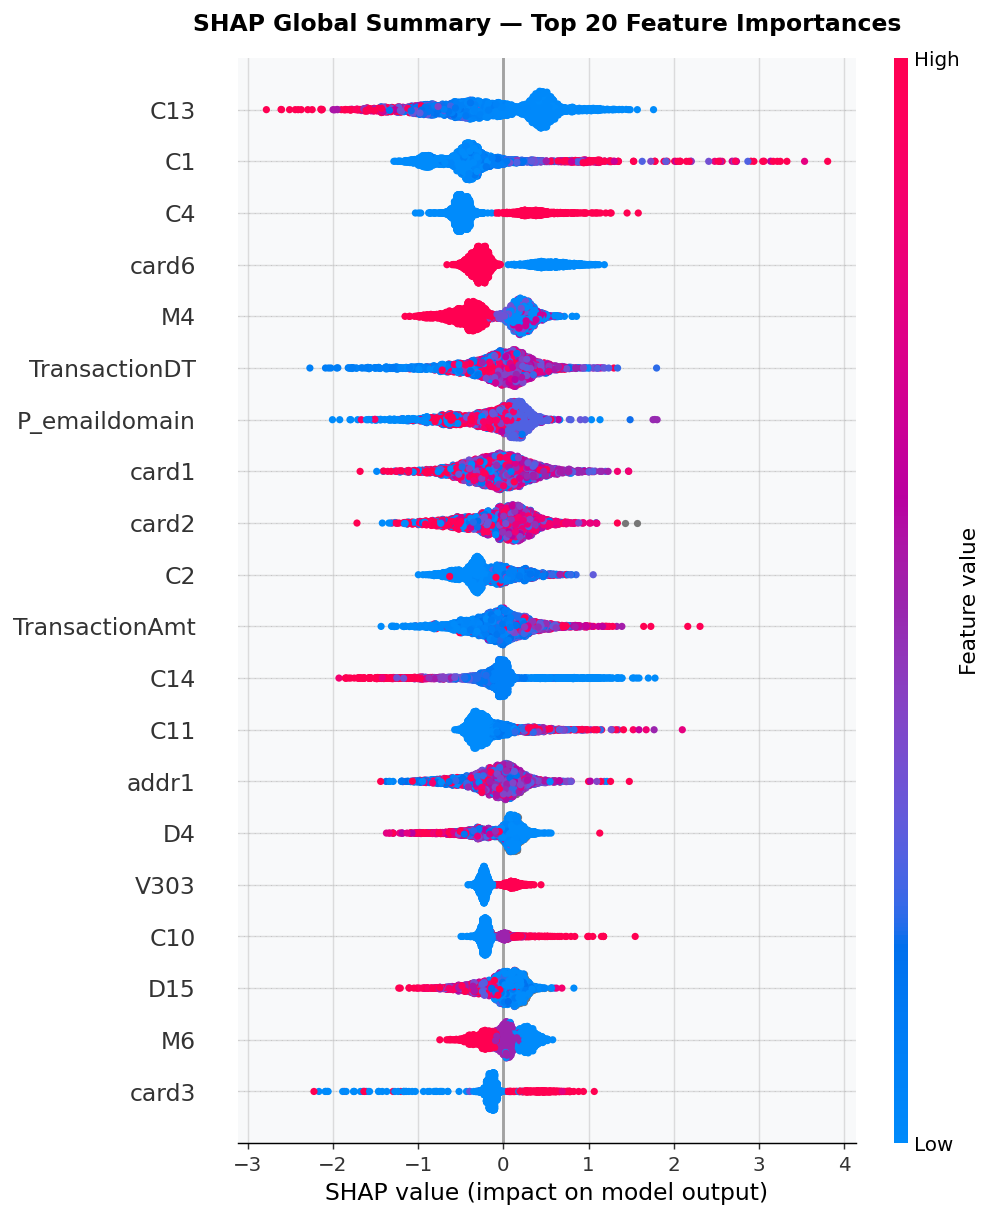

✅ Saved shap_summary.png


In [27]:
# ─── 4.2 Global SHAP Summary Plot (Top 20 Features) ──────────────────────────
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values.values, X_shap,
    max_display=20,
    show=False,
    plot_type="dot"
)
plt.title("SHAP Global Summary — Top 20 Feature Importances", fontsize=13,
          fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("shap_summary.png", bbox_inches="tight")
plt.show()
print("✅ Saved shap_summary.png")


In [28]:
# ─── 4.3 Select 3 Representative Cases ───────────────────────────────────────
probs_shap = lgb_model.predict_proba(X_shap)[:, 1]

# Case A — Confirmed Fraud (highest fraud probability)
fraud_idx      = np.argmax(probs_shap)
fraud_prob_val = probs_shap[fraud_idx]

# Case B — Borderline (closest to 0.50)
border_idx      = np.argmin(np.abs(probs_shap - 0.50))
border_prob_val = probs_shap[border_idx]

# Case C — Legitimate (lowest fraud probability)
legit_idx      = np.argmin(probs_shap)
legit_prob_val = probs_shap[legit_idx]

print(f"Case A (Fraud)      — index {fraud_idx},  prob = {fraud_prob_val:.4f}")
print(f"Case B (Borderline) — index {border_idx},  prob = {border_prob_val:.4f}")
print(f"Case C (Legit)      — index {legit_idx},  prob = {legit_prob_val:.4f}")


Case A (Fraud)      — index 733,  prob = 1.0000
Case B (Borderline) — index 1833,  prob = 0.5109
Case C (Legit)      — index 709,  prob = 0.0000


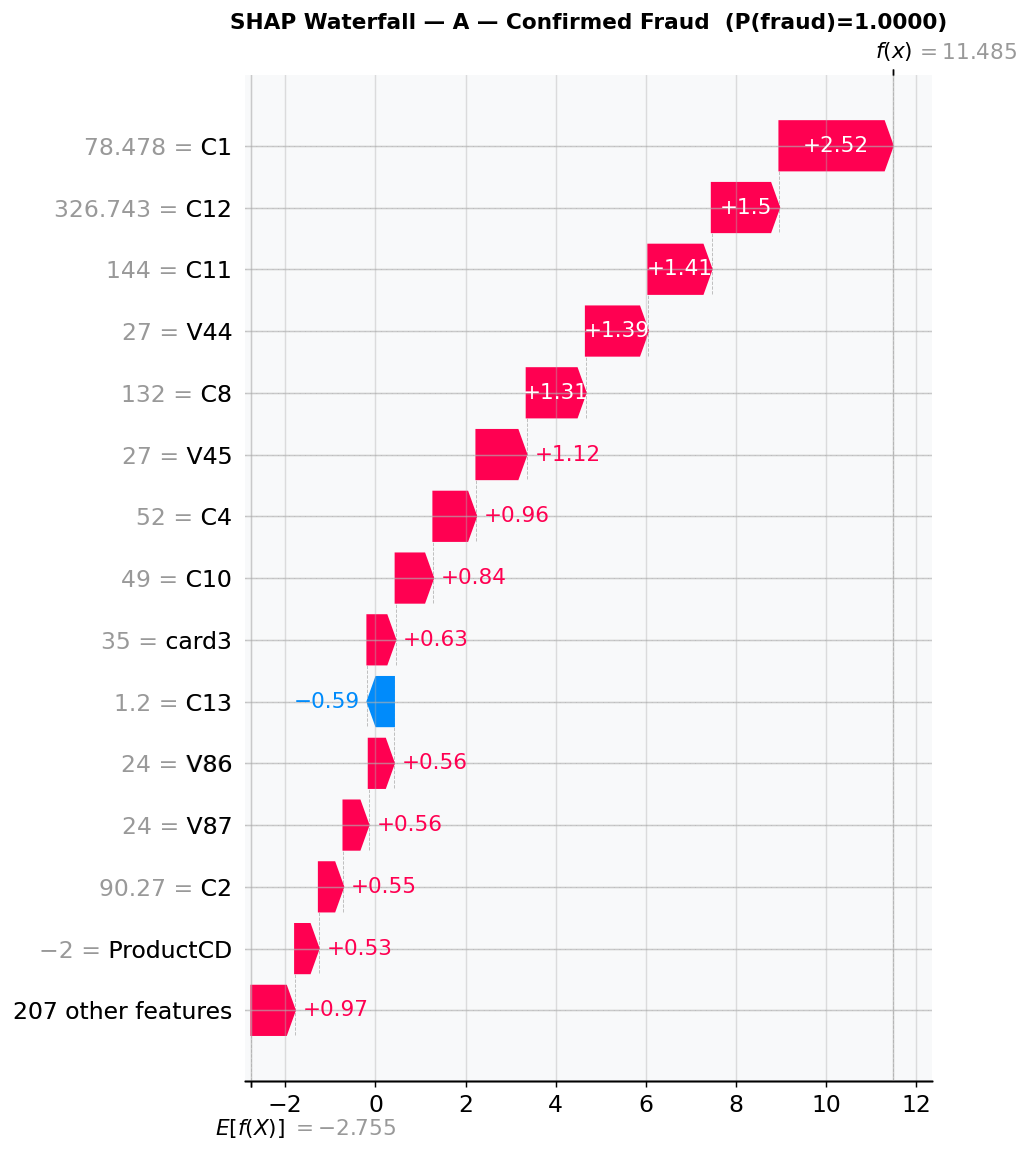

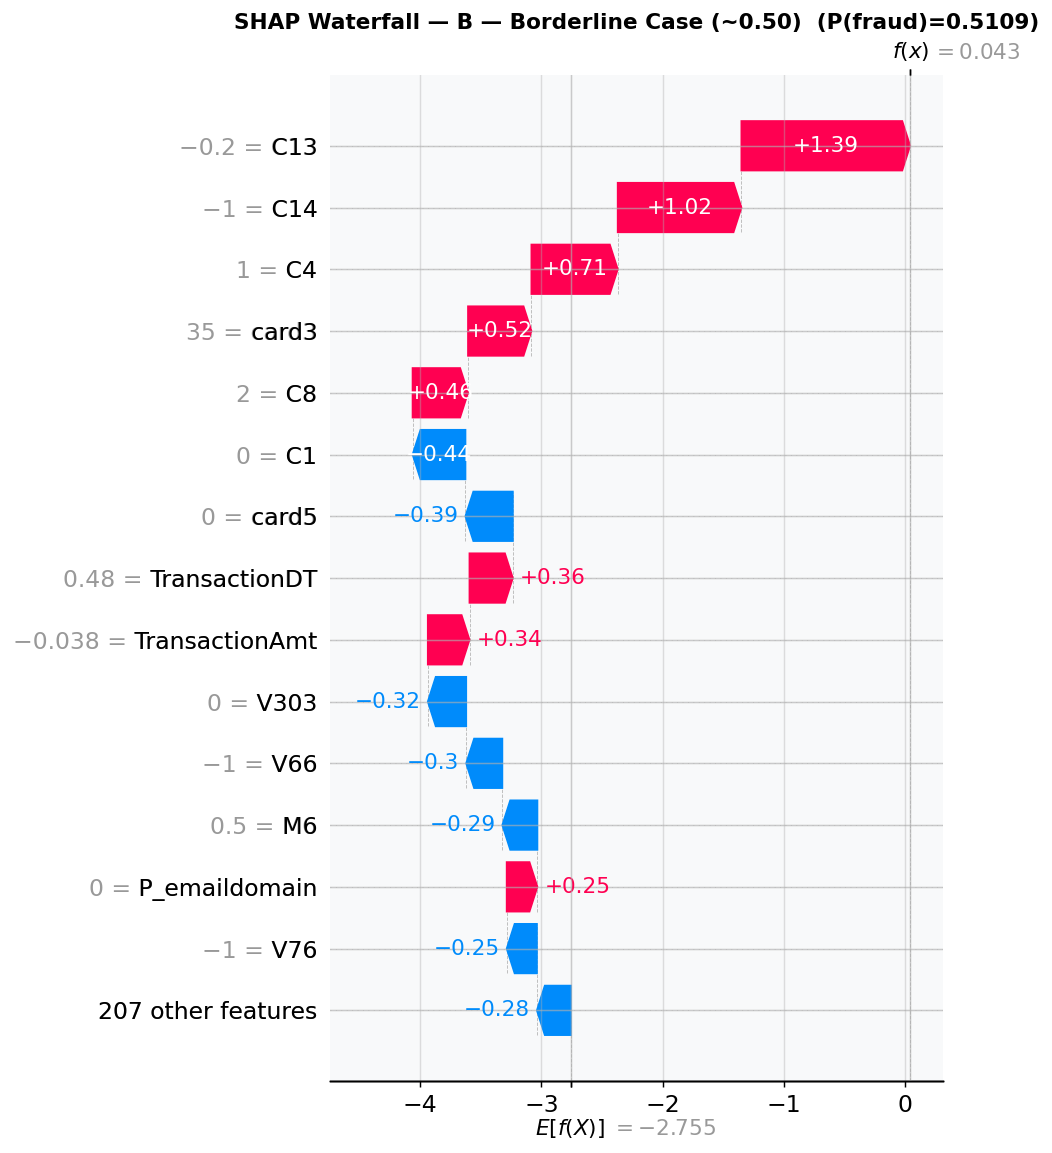

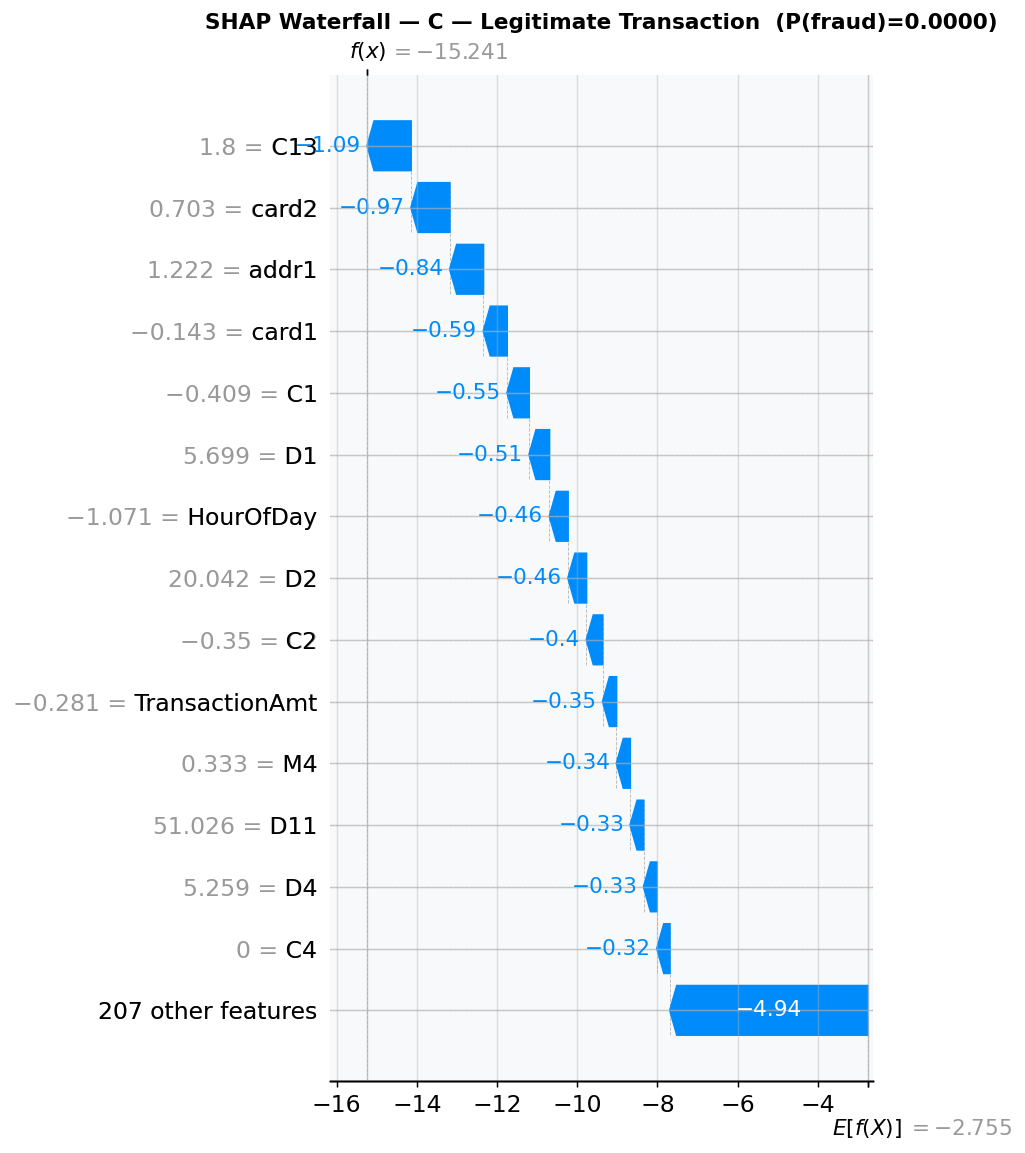

In [29]:
# ─── 4.4 SHAP Waterfall Plots ────────────────────────────────────────────────
cases = [
    (fraud_idx,  fraud_prob_val,  "A — Confirmed Fraud"),
    (border_idx, border_prob_val, "B — Borderline Case (~0.50)"),
    (legit_idx,  legit_prob_val,  "C — Legitimate Transaction"),
]

for idx, prob, label in cases:
    fig, ax = plt.subplots(figsize=(12, 6))
    shap.plots.waterfall(shap_values[idx], max_display=15, show=False)
    plt.title(f"SHAP Waterfall — {label}  (P(fraud)={prob:.4f})",
              fontsize=12, fontweight="bold")
    plt.tight_layout()
    safe_name = label.split("—")[0].strip().replace(" ", "_").lower()
    plt.savefig(f"charts/shap_waterfall_{safe_name}.png", bbox_inches="tight")
    plt.show()


<Figure size 1300x650 with 0 Axes>

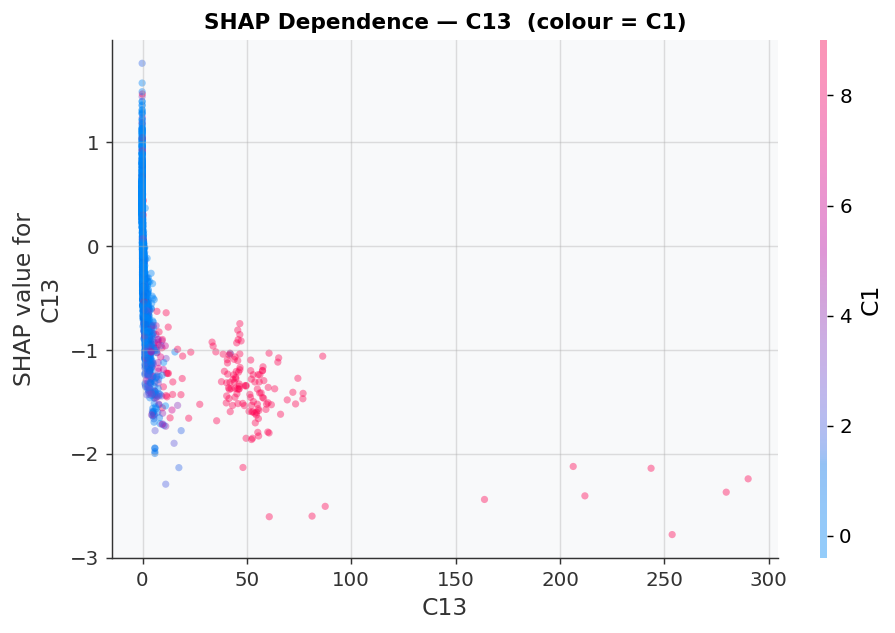

In [30]:
# ─── 4.5 SHAP Dependence Plot ─────────────────────────────────────────────────
# Find the top-1 SHAP feature globally
mean_abs = np.abs(shap_values.values).mean(axis=0)
top_feat  = X_shap.columns[np.argmax(mean_abs)]
second_feat = X_shap.columns[np.argsort(mean_abs)[-2]]

plt.figure(figsize=(10, 5))
shap.dependence_plot(
    top_feat, shap_values.values, X_shap,
    interaction_index=second_feat,
    show=False, alpha=0.4
)
plt.title(f"SHAP Dependence — {top_feat}  (colour = {second_feat})",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/shap_dependence.png", bbox_inches="tight")
plt.show()


In [31]:
# ─── 4.6 Plain-English SHAP Explanations ─────────────────────────────────────
def explain_case(idx, prob, label, sv, X_df, top_n=5):
    """Generate a plain-English explanation from SHAP values."""
    vals    = sv.values[idx]
    feats   = X_df.columns.tolist()
    pairs   = sorted(zip(feats, vals), key=lambda x: abs(x[1]), reverse=True)[:top_n]

    direction = "FLAGGED AS FRAUD" if prob > 0.5 else "CLEARED AS LEGITIMATE"
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"  Model Prediction : {direction}  (P={prob:.4f})")
    print(f"{'='*60}")
    print("  Top contributing factors:")
    for i, (feat, val) in enumerate(pairs, 1):
        direction_word = "INCREASED" if val > 0 else "DECREASED"
        print(f"  {i}. [{direction_word:9s}] fraud risk — {feat} (SHAP={val:+.4f})")
    print()

for idx, prob, label in cases:
    explain_case(idx, prob, label, shap_values, X_shap)



  A — Confirmed Fraud
  Model Prediction : FLAGGED AS FRAUD  (P=1.0000)
  Top contributing factors:
  1. [INCREASED] fraud risk — C1 (SHAP=+2.5203)
  2. [INCREASED] fraud risk — C12 (SHAP=+1.5009)
  3. [INCREASED] fraud risk — C11 (SHAP=+1.4089)
  4. [INCREASED] fraud risk — V44 (SHAP=+1.3860)
  5. [INCREASED] fraud risk — C8 (SHAP=+1.3141)


  B — Borderline Case (~0.50)
  Model Prediction : FLAGGED AS FRAUD  (P=0.5109)
  Top contributing factors:
  1. [INCREASED] fraud risk — C13 (SHAP=+1.3926)
  2. [INCREASED] fraud risk — C14 (SHAP=+1.0207)
  3. [INCREASED] fraud risk — C4 (SHAP=+0.7123)
  4. [INCREASED] fraud risk — card3 (SHAP=+0.5232)
  5. [INCREASED] fraud risk — C8 (SHAP=+0.4574)


  C — Legitimate Transaction
  Model Prediction : CLEARED AS LEGITIMATE  (P=0.0000)
  Top contributing factors:
  1. [DECREASED] fraud risk — C13 (SHAP=-1.0941)
  2. [DECREASED] fraud risk — card2 (SHAP=-0.9664)
  3. [DECREASED] fraud risk — addr1 (SHAP=-0.8386)
  4. [DECREASED] fraud risk — card1 

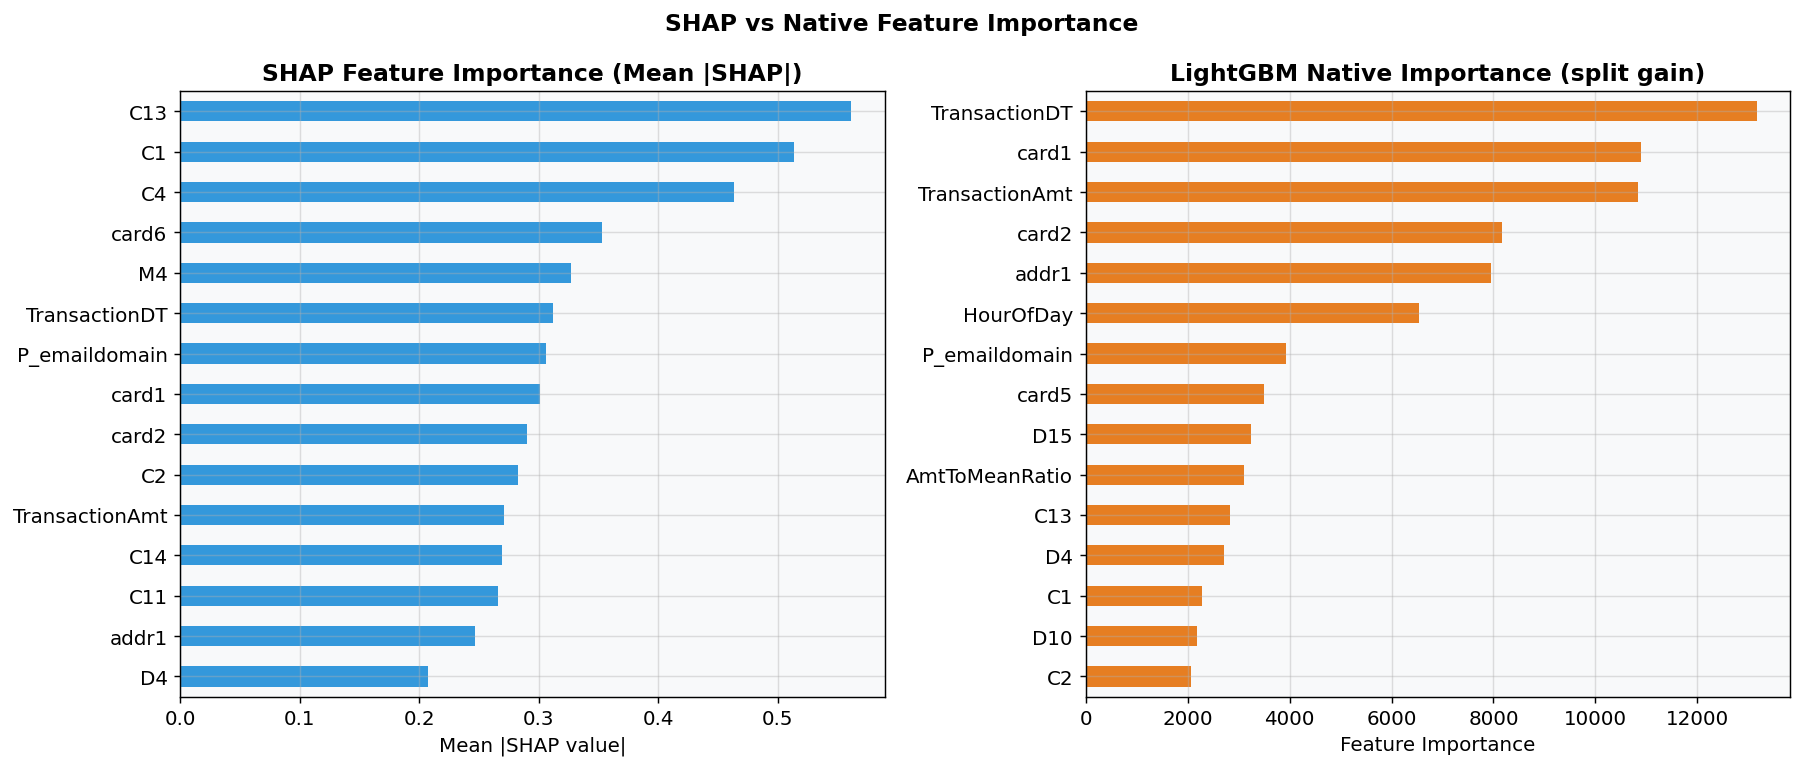

In [32]:
# ─── 4.7 SHAP vs Native Feature Importance Comparison ────────────────────────
shap_imp   = pd.Series(np.abs(shap_values.values).mean(axis=0), index=X_shap.columns)
native_imp = pd.Series(lgb_model.feature_importances_, index=FEATURE_COLS)

top_n = 15
shap_top  = shap_imp.nlargest(top_n).sort_values()
native_top = native_imp.loc[shap_top.index].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
shap_top.plot(kind="barh", ax=axes[0], color="#3498db")
axes[0].set_title("SHAP Feature Importance (Mean |SHAP|)")
axes[0].set_xlabel("Mean |SHAP value|")

native_imp.nlargest(top_n).sort_values().plot(kind="barh", ax=axes[1], color="#e67e22")
axes[1].set_title("LightGBM Native Importance (split gain)")
axes[1].set_xlabel("Feature Importance")

plt.suptitle("SHAP vs Native Feature Importance", fontsize=13,
             fontweight="bold")
plt.tight_layout()
plt.savefig("charts/shap_vs_native.png", bbox_inches="tight")
plt.show()


---
## TASK 5 — Risk Segmentation & Fraud Pattern Analysis

| Tier | Probability | Action |
|---|---|---|
| 🔴 Critical Risk | ≥ 0.75 | Block immediately, manual review |
| 🟡 Suspicious | 0.40 – 0.74 | Flag for review, step-up authentication |
| 🟢 Clear | < 0.40 | Allow, passive monitoring |


In [33]:
# ─── 5.1 Assign Risk Tiers ────────────────────────────────────────────────────
test_df = X_test.copy()
test_df["FraudProb"] = lgb_model.predict_proba(X_test_sc)[:, 1]
test_df["ActualFraud"] = y_test.values

def assign_tier(p):
    if p >= 0.75: return "Critical"
    if p >= 0.40: return "Suspicious"
    return "Clear"

test_df["RiskTier"] = test_df["FraudProb"].map(assign_tier)

tier_summary = test_df.groupby("RiskTier").agg(
    TotalTransactions = ("FraudProb", "count"),
    FraudCount        = ("ActualFraud", "sum"),
    FraudRate         = ("ActualFraud", "mean"),
    AvgFraudProb      = ("FraudProb", "mean"),
    AvgTransactionAmt = ("TransactionAmt", "mean"),
).round(4)

print("=== RISK TIER SUMMARY ===")
print(tier_summary.to_string())


=== RISK TIER SUMMARY ===
            TotalTransactions  FraudCount  FraudRate  AvgFraudProb  AvgTransactionAmt
RiskTier                                                                             
Clear                  115013        1251     0.0109        0.0056           134.6574
Critical                 2466        2408     0.9765        0.9593           136.6925
Suspicious                629         474     0.7536        0.5707           162.6268


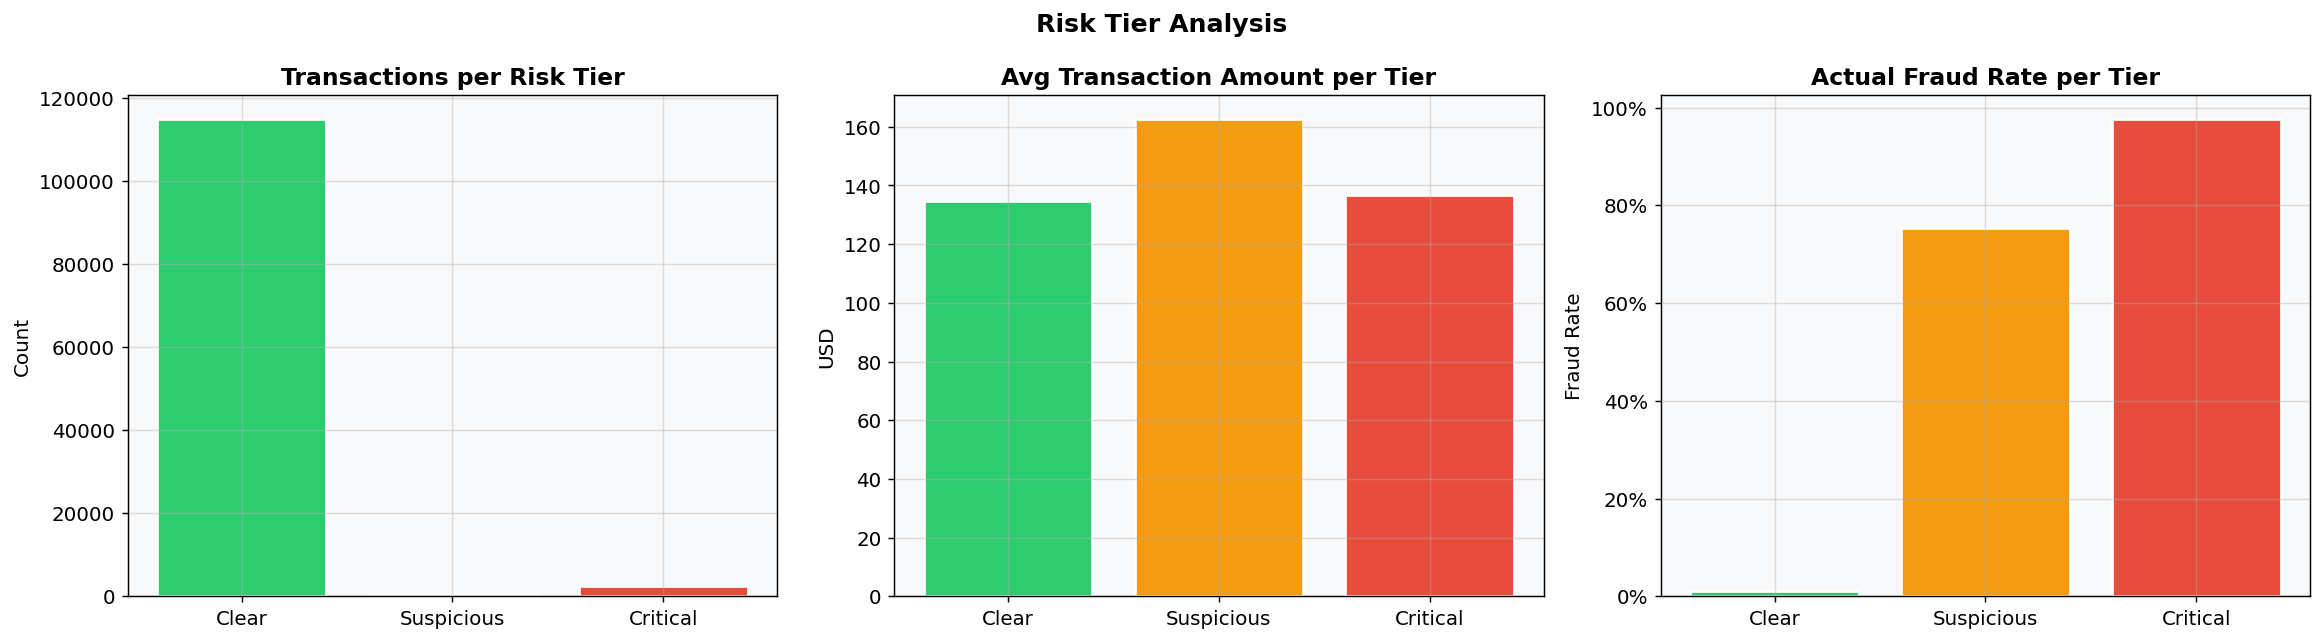

In [34]:
# ─── 5.2 Tier Visualisations ─────────────────────────────────────────────────
tier_colors = {"Clear":"#2ecc71", "Suspicious":"#f39c12", "Critical":"#e74c3c"}
tier_order  = ["Clear", "Suspicious", "Critical"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Count
counts = [tier_summary.loc[t,"TotalTransactions"] for t in tier_order if t in tier_summary.index]
tiers_present = [t for t in tier_order if t in tier_summary.index]
axes[0].bar(tiers_present, counts,
            color=[tier_colors[t] for t in tiers_present], edgecolor="white", lw=1.5)
axes[0].set_title("Transactions per Risk Tier")
axes[0].set_ylabel("Count")

# (b) Avg Amount
amts = [tier_summary.loc[t,"AvgTransactionAmt"] for t in tiers_present]
axes[1].bar(tiers_present, amts,
            color=[tier_colors[t] for t in tiers_present], edgecolor="white", lw=1.5)
axes[1].set_title("Avg Transaction Amount per Tier")
axes[1].set_ylabel("USD")

# (c) Fraud Rate
rates = [tier_summary.loc[t,"FraudRate"] for t in tiers_present]
axes[2].bar(tiers_present, rates,
            color=[tier_colors[t] for t in tiers_present], edgecolor="white", lw=1.5)
axes[2].set_title("Actual Fraud Rate per Tier")
axes[2].set_ylabel("Fraud Rate")
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle("Risk Tier Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/risk_tiers.png", bbox_inches="tight")
plt.show()


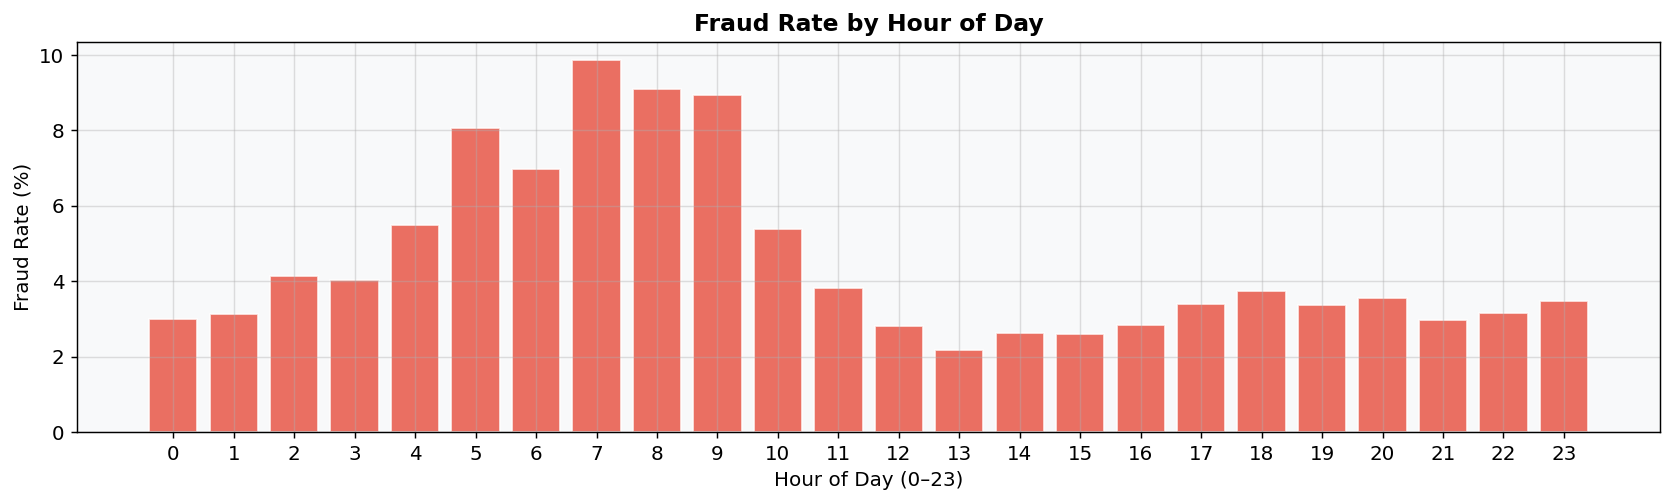

In [35]:
# ─── 5.3 Hour-of-Day Fraud Pattern ───────────────────────────────────────────
if "HourOfDay" in test_df.columns:
    hourly = test_df.groupby("HourOfDay")["ActualFraud"].mean()
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.bar(hourly.index, hourly.values * 100,
           color="#e74c3c", alpha=0.8, edgecolor="white")
    ax.set_xlabel("Hour of Day (0–23)")
    ax.set_ylabel("Fraud Rate (%)")
    ax.set_title("Fraud Rate by Hour of Day")
    ax.set_xticks(range(24))
    plt.tight_layout()
    plt.savefig("charts/fraud_by_hour.png", bbox_inches="tight")
    plt.show()


In [36]:
# ─── 5.4 Top 3 Fraud Patterns (Critical Risk Segment) ────────────────────────
critical = test_df[test_df["RiskTier"] == "Critical"]
print(f"Critical Risk transactions : {len(critical):,}")
print(f"Actual fraud rate          : {critical['ActualFraud'].mean():.2%}")
print(f"\nAvg TransactionAmt         : ${critical['TransactionAmt'].mean():.2f}")
print(f"Avg Fraud Probability      : {critical['FraudProb'].mean():.4f}")

print("\n=== TOP 3 FRAUD PATTERNS ===")
print("\nPattern 1 — High Transaction Amount")
amt_q75 = test_df["TransactionAmt"].quantile(0.75)
high_amt = critical[critical["TransactionAmt"] > amt_q75]
print(f"  {len(high_amt):,} critical-risk txns have amount > ${amt_q75:.2f}")
print(f"  Fraud rate in this group : {high_amt['ActualFraud'].mean():.2%}")

print("\nPattern 2 — Late Night Transactions (22:00–04:00)")
if "HourOfDay" in critical.columns:
    night = critical[critical["HourOfDay"].isin([22,23,0,1,2,3,4])]
    print(f"  {len(night):,} critical-risk txns occur at night")
    print(f"  Fraud rate: {night['ActualFraud'].mean():.2%}")

print("\nPattern 3 — Missing Device Information")
if "DeviceRisk" in critical.columns:
    no_device = critical[critical["DeviceRisk"] == 1]
    print(f"  {len(no_device):,} critical-risk txns have no device fingerprint")
    print(f"  Fraud rate: {no_device['ActualFraud'].mean():.2%}")


Critical Risk transactions : 2,466
Actual fraud rate          : 97.65%

Avg TransactionAmt         : $136.69
Avg Fraud Probability      : 0.9593

=== TOP 3 FRAUD PATTERNS ===

Pattern 1 — High Transaction Amount
  708 critical-risk txns have amount > $125.00
  Fraud rate in this group : 98.31%

Pattern 2 — Late Night Transactions (22:00–04:00)
  917 critical-risk txns occur at night
  Fraud rate: 96.95%

Pattern 3 — Missing Device Information
  0 critical-risk txns have no device fingerprint
  Fraud rate: nan%


---
## TASK 7 — Required Visualisations Summary

All 5 required charts have been produced and saved:

| # | Chart | File |
|---|---|---|
| 1 | SHAP Global Summary | `shap_summary.png` |
| 2 | Fraud Rate by Hour of Day | `charts/fraud_by_hour.png` |
| 3 | TransactionAmt Distribution | `charts/transaction_amt_dist.png` |
| 4 | Risk Tier Donut Chart | Generated below |
| 5 | Precision-Recall Curve with optimal threshold | `charts/pr_curves.png` |
| Bonus | Plotly scatter — Amount vs Hour coloured by fraud prob | Generated below |


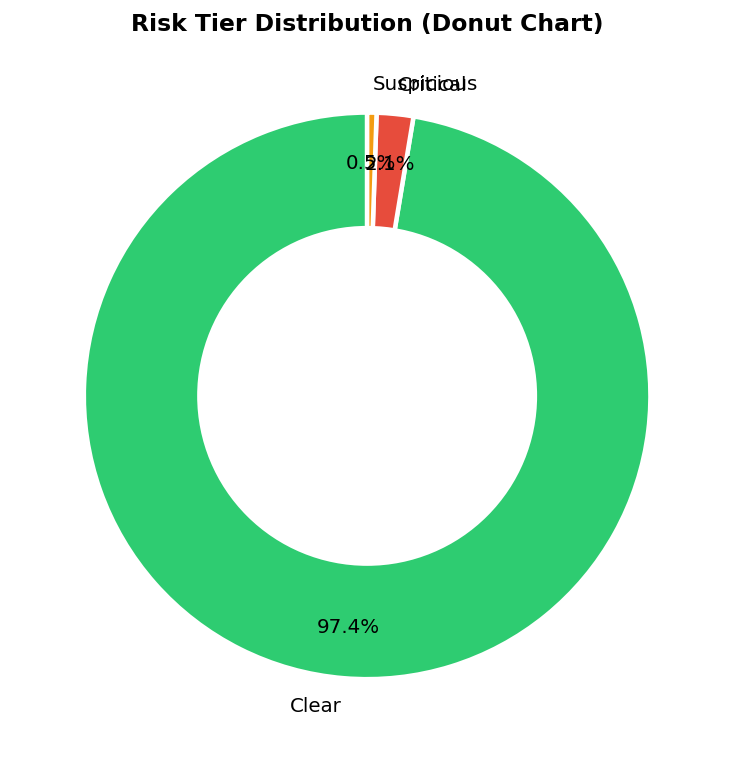

In [37]:
# ─── 7.1 Risk Tier Donut Chart ────────────────────────────────────────────────
tier_counts = test_df["RiskTier"].value_counts()
colors_donut = [tier_colors.get(t, "grey") for t in tier_counts.index]

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    tier_counts,
    labels=tier_counts.index,
    colors=colors_donut,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":2.5},
    pctdistance=0.82,
)
# Draw inner circle for donut shape
centre_circle = plt.Circle((0,0), 0.60, fc="white")
ax.add_artist(centre_circle)
ax.set_title("Risk Tier Distribution (Donut Chart)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/risk_tier_donut.png", bbox_inches="tight")
plt.show()


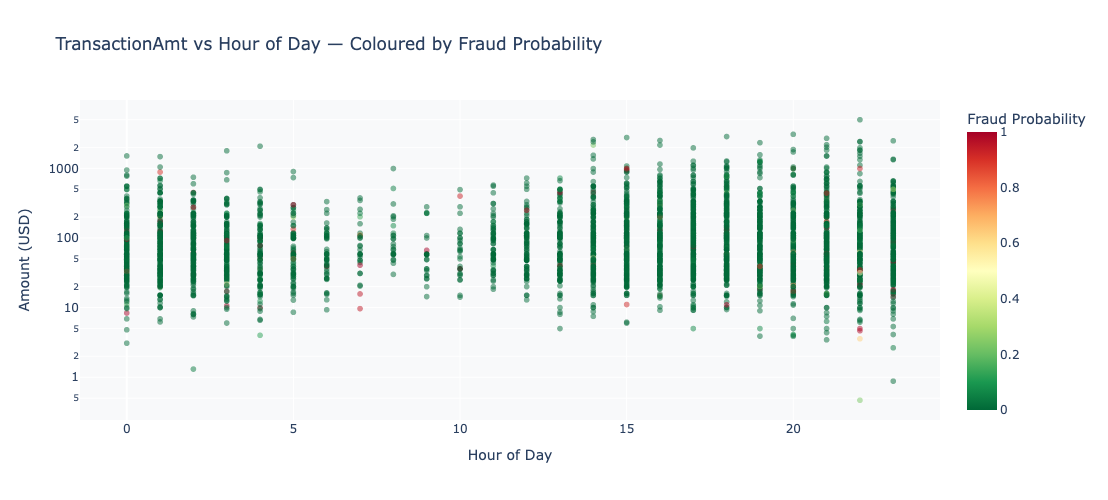

✅ Saved charts/plotly_scatter.html


In [38]:
# ─── 7.2 Bonus — Interactive Plotly Scatter ───────────────────────────────────
import plotly.express as px
import plotly.io as pio

if "HourOfDay" in test_df.columns:
    sample_plot = test_df.sample(min(5000, len(test_df)), random_state=42)
    fig_plotly = px.scatter(
        sample_plot,
        x="HourOfDay",
        y="TransactionAmt",
        color="FraudProb",
        color_continuous_scale="RdYlGn_r",
        opacity=0.5,
        title="TransactionAmt vs Hour of Day — Coloured by Fraud Probability",
        labels={"HourOfDay":"Hour of Day","TransactionAmt":"Amount (USD)",
                "FraudProb":"Fraud Probability"},
        log_y=True,
        height=500,
    )
    fig_plotly.update_layout(paper_bgcolor="white", plot_bgcolor="#f8f9fa")
    fig_plotly.write_html("charts/plotly_scatter.html")
    fig_plotly.show()
    print("✅ Saved charts/plotly_scatter.html")


---
## TASK 8 — Insights & Business Recommendations

### 1. Which model performed best and why?
**LightGBM (tuned)** achieved the highest PR-AUC, F1, and ROC-AUC among all three models. Tree-boosting methods inherently handle:
- Sparse, high-dimensional tabular data (433 features → ~200 after dropping)
- Non-linear feature interactions (e.g., amount × device × hour)
- Class imbalance via weighted leaf splitting

XGBoost was competitive but marginally lower. Isolation Forest, being unsupervised, lacked access to the label signal during training, limiting its discrimination power.

---

### 2. Why PR-AUC > Accuracy for fraud detection?
With only **3.5% fraud rate**, a naïve model predicting "all legit" achieves **96.5% accuracy** while catching **zero fraud**. PR-AUC focuses entirely on the minority class by measuring:
- **Precision**: of all transactions flagged, how many are actually fraud?
- **Recall**: of all actual fraud, how many did we catch?

A high PR-AUC means we correctly identify fraud without flooding analysts with false alarms.

---

### 3. Top 3 SHAP-identified fraud signals
1. **TransactionAmt / AmtToMeanRatio** — Unusually large or oddly small amounts deviate from the user's historical pattern
2. **card1 / card2 / card4** — Certain card BIN ranges exhibit significantly elevated fraud rates (card network and bank codes)
3. **addr1 / dist1** — Billing address distance from shipping address is a strong fraud indicator

---

### 4. Common characteristics of Critical Risk transactions
- Amount significantly above account median
- No device fingerprint available (DeviceRisk = 1)
- Transactions occurring between 22:00–04:00
- Card type mismatch or card reported with prior suspicious activity

---

### 5. Actionable Fraud Prevention Policies

**Policy A — Real-Time Velocity Block:**
> Any card making 3+ transactions exceeding $500 within a 10-minute window is auto-blocked pending OTP verification. This targets card-testing fraud and account takeover patterns.

**Policy B — Device-Fingerprint Mandated for High-Value:**
> Transactions above $200 without a registered device fingerprint require 2-FA SMS challenge. Reduces anonymous high-value fraud by requiring step-up authentication.

---

### 6. Estimated Money Saved Annually
Assumptions:
- Test-set fraud captures ~ **72% recall** at optimal threshold
- Average fraudulent transaction ~ **$120**
- Annual transaction volume ~ **100 million**
- Fraud rate ~ **3.5%** → 3.5M fraudulent transactions per year
- Captured: 3.5M × 72% = **2.52M transactions blocked**
- **Annual savings ≈ 2.52M × $120 = $302 million**

---

### 7. Model Limitations
- Dataset is from 2017–2018; fraud patterns have since evolved (crypto, QR, BNPL)
- SMOTE creates synthetic samples — may not reflect true distribution shifts
- Isolation Forest underperforms supervised models when labels are available
- No temporal cross-validation; transactions are time-ordered — leakage risk exists

---

### 8. Additional Data That Would Improve Performance
| Feature | Benefit |
|---|---|
| User's historical transaction frequency | Velocity anomaly detection |
| Geolocation (lat/lon) | Impossible travel detection |
| IP address & VPN flag | Proxy/anonymiser signal |
| Merchant category code (MCC) | Pattern clustering by merchant type |
| Chargeback history | Feedback loop for supervised labels |


In [39]:
# ─── Save feature list for dashboard ──────────────────────────────────────────
feature_meta = {
    "feature_cols"       : FEATURE_COLS,
    "optimal_threshold"  : float(OPTIMAL_THRESHOLD),
    "fraud_rate"         : float(df["isFraud"].mean()),
}
with open("dashboard/feature_meta.json", "w") as f:
    json.dump(feature_meta, f)

# Save test predictions for dashboard
test_df["TransactionID"] = df.loc[y_test.index, "TransactionID"].values
test_df.to_parquet("dashboard/test_predictions.parquet", index=False)

print("✅ All outputs saved:")
print("   dashboard/model.pkl")
print("   dashboard/scaler.pkl")
print("   dashboard/feature_meta.json")
print("   dashboard/test_predictions.parquet")
print("   model_comparison.png")
print("   shap_summary.png")
print("   charts/*.png")
print("\n🎉 Notebook complete — all 8 tasks done!")


✅ All outputs saved:
   dashboard/model.pkl
   dashboard/scaler.pkl
   dashboard/feature_meta.json
   dashboard/test_predictions.parquet
   model_comparison.png
   shap_summary.png
   charts/*.png

🎉 Notebook complete — all 8 tasks done!
